# Домашнее задание 2. Микросервисная архитектура
Студент: *Ртищева Алена Сергеевна*, M08-501НД, 5.04.2026

Это задание выполняется в рамках модуля 2 «Микросервисная архитектура». Вы закрепите навыки разделения монолита на микросервисы.

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

## Подготовка окружения

In [1]:
%%capture
!sudo apt install graphviz
!pip install docker-compose-diagram
!pip install fastapi uvicorn[standard] -qq
!pip install --upgrade sqlalchemy

In [2]:
# Импорт функций для отображения картинок
from IPython.display import Image, display

### Задание 1. Сравнить монолитную и микросервисную архитектуру: преимущества и недостатки

В каком случае вы не будете разбивать монолит на микросервисы и почему?

В каком случае монолит обязательно разбивать на микросервисы и почему?

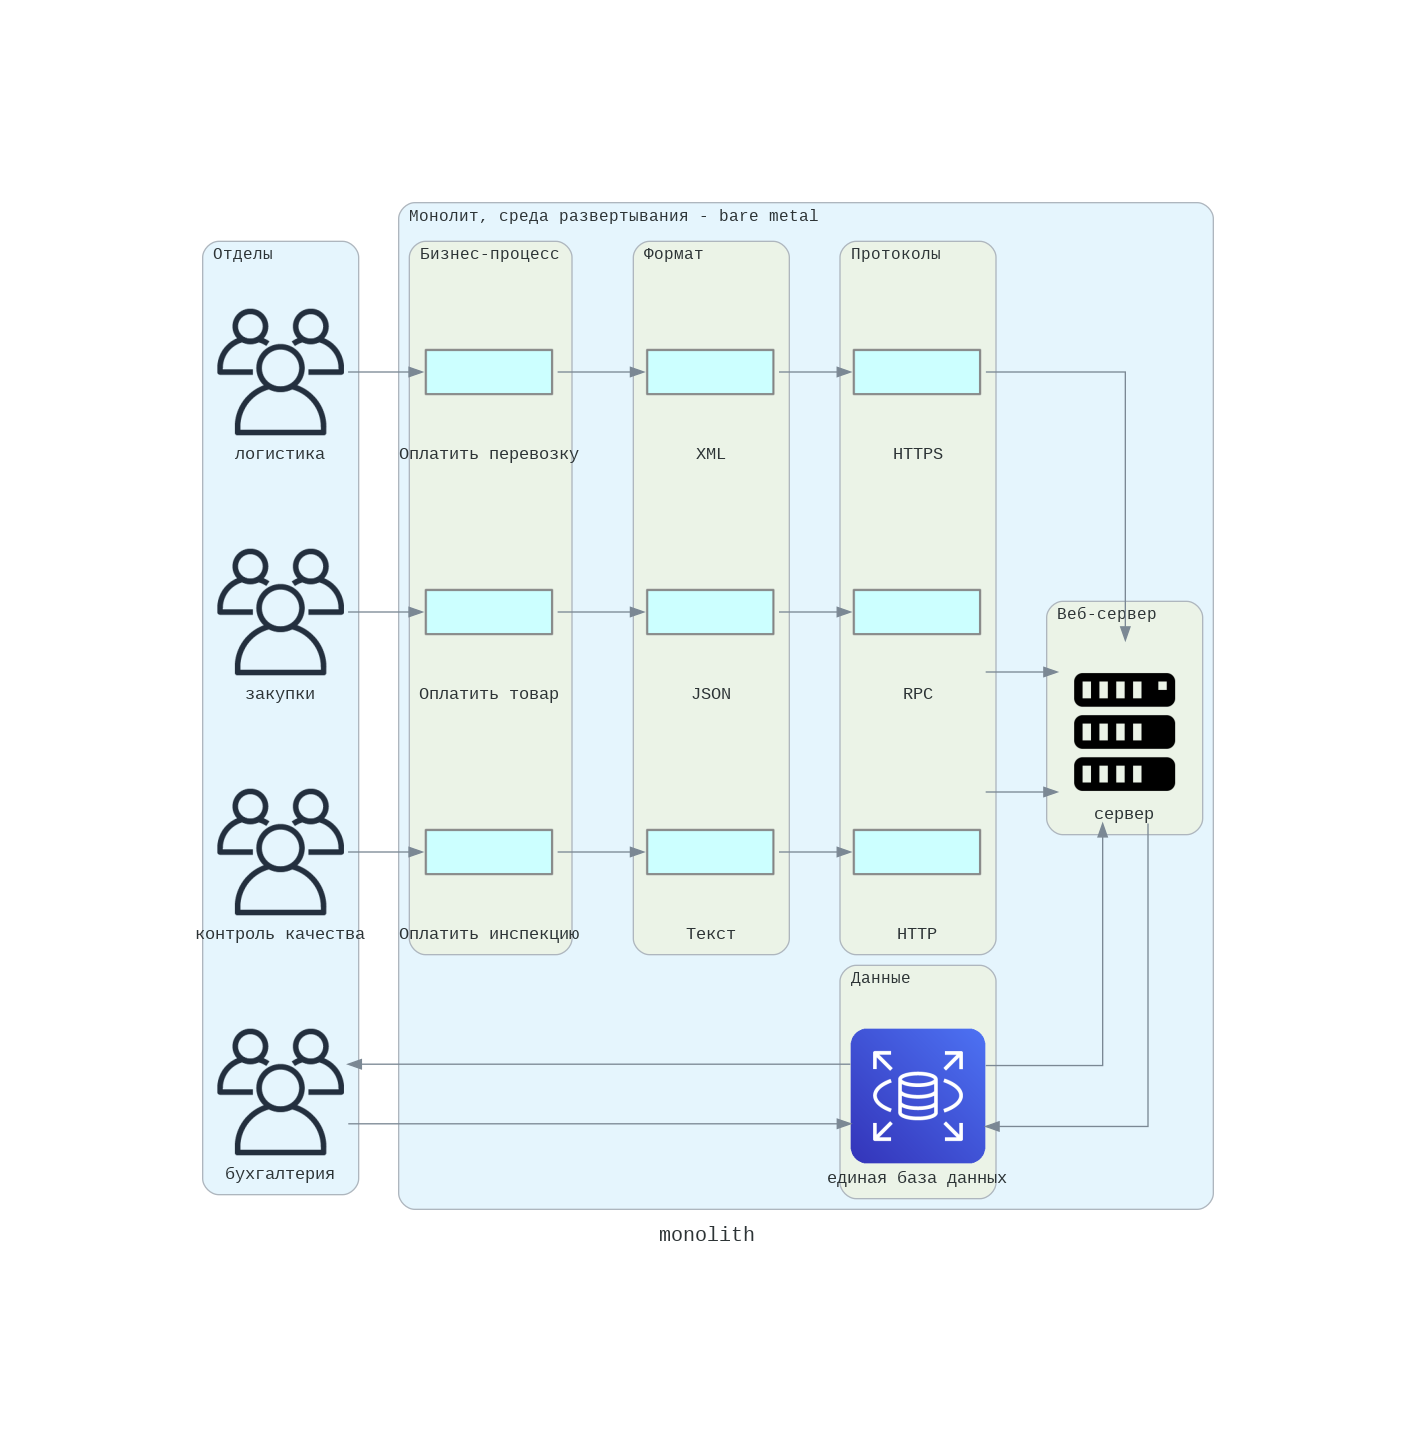

In [3]:
# За основу возьмем диаграмму из семинара

# Создаем файл с кодом диаграммы
with open("/content/monolith.py", "w") as f:
    f.write("""

# ------ Импортируем нужные компоненты для рисования
from diagrams import Cluster, Diagram
from diagrams.onprem.compute import Server         # Сервер
from diagrams.aws.database import RDS              # База данных
from diagrams.programming.flowchart import Action  # Действие
from diagrams.onprem.client import Users           # Пользователи/отделы

# ------ Создаем диаграмму с названием "monolith"
with Diagram("monolith", show=False):

    # ----- Отделы компании (кто использует систему)
    with Cluster("Отделы"):
        depts = [
            Users("логистика"),            # отдел логистики
            Users("закупки"),              # отдел закупок
            Users("контроль качества"),    # отдел контроля качества
            Users("бухгалтерия")           # бухгалтерия
        ]

    # ----- Монолит (само приложение)
    with Cluster("Монолит, среда развертывания - bare metal"):

        # ----- Данные (база данных)
        with Cluster("Данные"):
            storage = [RDS("единая база данных")]

        # ----- Веб-сервер
        with Cluster("Веб-сервер"):
            webserver = [Server("сервер")]

        # ------ Протоколы передачи данных
        with Cluster("Протоколы"):
            protocols = [
                Action("HTTPS"),     # защищенный протокол
                Action("RPC"),       # удаленный вызов процедур
                Action("HTTP")       # обычный протокол
            ]

        # ----- Форматы данных
        with Cluster("Формат"):
            formats = [
                Action("XML"),       # старый формат
                Action("JSON"),      # современный формат
                Action("Текст")      # простой текст
            ]

        # ------ Бизнес-процессы
        with Cluster("Бизнес-процесс"):
            process = [
                Action("Оплатить перевозку"),    # для логистики
                Action("Оплатить товар"),        # для закупок
                Action("Оплатить инспекцию")     # для контроля качества
            ]

    # ----- Связи (стрелки между компонентами)

    # ----- База данных и веб-сервер общаются друг с другом
    storage[0] >> webserver[0]   # БД -> сервер
    webserver[0] >> storage[0]   # сервер -> БД

    # ----- Бухгалтерия работает с базой данных напрямую
    storage[0] >> depts[3]        # БД -> бухгалтерия
    depts[3] >> storage[0]        # бухгалтерия -> БД

    # ------ Логистика: отправляет запрос на оплату перевозки
    depts[0] >> process[0] >> formats[0] >> protocols[0] >> webserver[0]

    # ------ Закупки: отправляют запрос на оплату товара
    depts[1] >> process[1] >> formats[1] >> protocols[1] >> webserver[0]

    # ------- Контроль качества: отправляет запрос на оплату инспекции
    depts[2] >> process[2] >> formats[2] >> protocols[2] >> webserver[0]
""")

# Запускаем созданный файл
!python /content/monolith.py

# Показываем получившуюся диаграмму
display(Image(filename='/content/monolith.png'))

**Ответы на вопросы**

1. В каком случае вы не будете разбивать монолит на микросервисы и почему?

  - Когда приложение небольшое - монолит удобен для небольших приложений. Если мы делаем маленький сервис, то разделять такое приложение совершенно необязательно.
  
  - Когда нет возможностей и средств - нет бюджета на микросервисную архитектуру. В монолите компоненты взаимодействуют напрямую - не через api, а прямо в коде. Это дешевле и не требует сложной инфраструктуры.
  
  - Когда команда - новички, при старте новых проектов монолит более понятен. Когда приложение вырастает во что-то крупное, тогда можно подумать о переходе на микросервисы. Но начинать лучше с простого.
  
  - Когда мало пользователей монолит легко справляется с нагрузкой. Микросервисы в такой ситуации только усложнят систему.
  
  - Когда все работает хорошо-— если монолит работает быстро, стабильно и устраивает пользователей, нет смысла его трогать.


2. В каком случае монолит обязательно разбивать на микросервисы и почему?

  - Когда приложение большое и много пользователей - монолит не выдерживает нагрузку: тормозит, падает, пользователи недовольны. Микросервисы позволяют масштабировать только нагруженные части.
  
  - Когда большая команда разработчиков.Микросервисы позволяют разработчикам работать независимо.
  
  - Когда используются разные технологии - разные части приложения могут быть реализованы на разных языках программирования. Микросервисы позволяют использовать лучший инструмент для каждой задачи.
  
  - Когда нужно обновлять сервисы без остановки всей системы. В монолите любое изменение требует перезапуска всего приложения. В микросервисах можно обновлять сервисы по очереди, без остановки системы.
  
  - Когда нужна высокая отказоустойчивость - ошибка в одном модуле не должна ломать все приложение.
  
  - Когда разные части имеют разную нагрузку. В монолите придется масштабировать все. В микросервисах - только нагруженную часть.

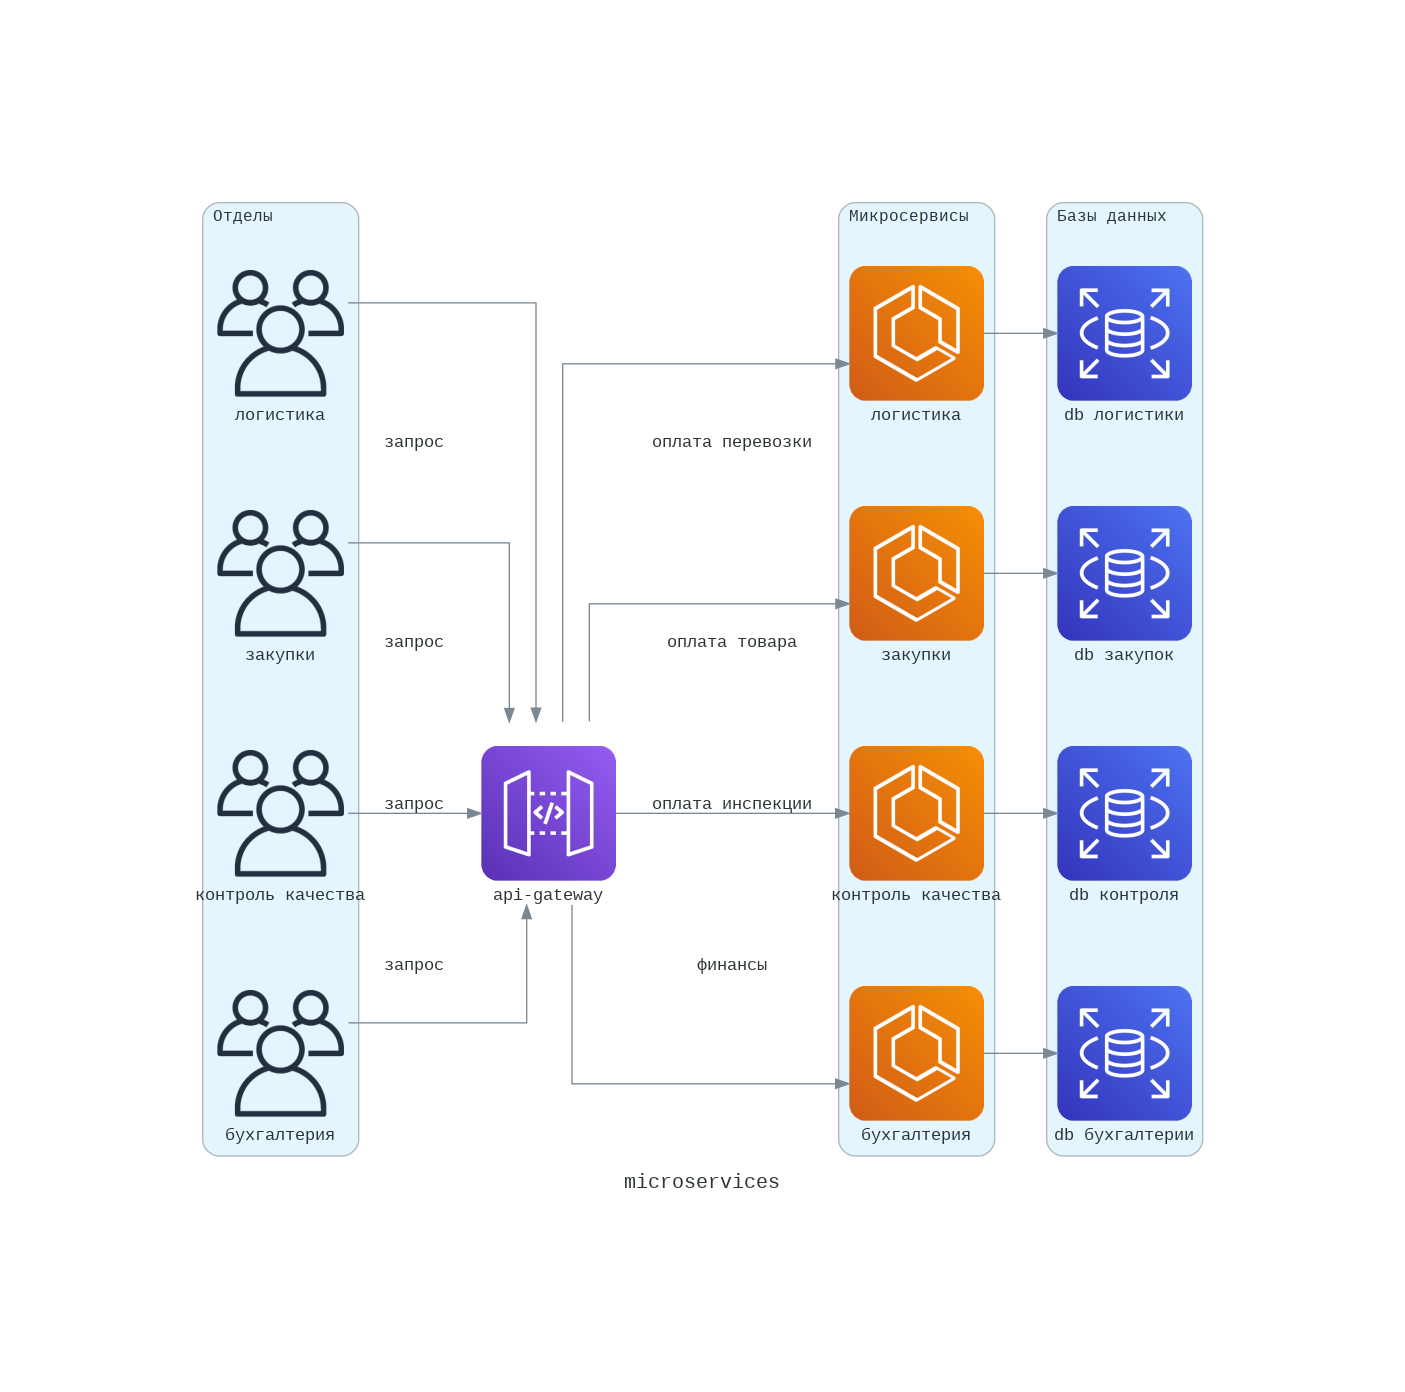

In [4]:
# Пример разбивки на микросервесы

# При разбиении монолита выделялись четкие границы между отделами.
# Для каждого отдела создан отдельный микросервис со своей базой данных,
# что позволяет развивать и масштабировать их независимо.
# Добавлен api-gateway, который принимает все запросы от отделов
# и перенаправляет их к нужным сервисам.

# ECS - это контейнер (микросервис)
# RDS	- это база данных

# Создаем файл с кодом диаграммы микросервисов
with open("/content/microservices.py", "w") as f:
    f.write("""

# ------ Импортируем нужные компоненты для рисования
from diagrams import Cluster, Diagram, Edge
from diagrams.aws.compute import ECS              # Контейнер (микросервис)
from diagrams.aws.network import APIGateway       # Входной шлюз API
from diagrams.aws.database import RDS, Dynamodb   # Базы данных
from diagrams.aws.integration import SQS          # Очередь сообщений
from diagrams.onprem.client import Users          # Пользователи/отделы
from diagrams.programming.flowchart import Action # Действие

# ------ Создаем диаграмму с названием "microservices"
with Diagram("microservices", show=False):


    # ----- Отделы компании

    with Cluster("Отделы"):
        depts = [
            Users("логистика"),            # отдел логистики
            Users("закупки"),              # отдел закупок
            Users("контроль качества"),    # отдел контроля качества
            Users("бухгалтерия")           # бухгалтерия
        ]

    # ----- API-Gateway (входной шлюз)
    gateway = APIGateway("api-gateway")

   # ----- Микросервисы
    with Cluster("Микросервисы"):
        logistics_service = ECS("логистика")
        procurement_service = ECS("закупки")
        quality_service = ECS("контроль качества")
        accounting_service= ECS("бухгалтерия")

    # ------ Базы данных (у каждого своя)
    with Cluster("Базы данных"):
        logistics_database = RDS("db логистики")
        procurement_database = RDS("db закупок")
        quality_database = RDS("db контроля")
        accounting_database = RDS("db бухгалтерии")

    # ----- Связи
    for dept in depts:
        dept >> Edge(label="запрос") >> gateway

    gateway >> Edge(label="оплата перевозки") >> logistics_service >> logistics_database
    gateway >> Edge(label="оплата товара") >> procurement_service >> procurement_database
    gateway >> Edge(label="оплата инспекции") >> quality_service >> quality_database
    gateway >> Edge(label="финансы") >> accounting_service >> accounting_database

""")

# Запускаем созданный файл
!python /content/microservices.py

# Показываем диаграмму
display(Image(filename='/content/microservices.png'))

**Вывод**

Проведено сравнение монолитной и микросервисной архитектур, выделены их преимущества и недостатки, определены критерии для выбора подхода.

Монолит проще в разработке и дешевле в поддержке, поэтому его целесообразно использовать для небольших проектов, при ограниченном бюджете, маленькой команде или когда все работает стабильно. Однако с ростом нагрузки и размера команды монолит становится проблемным: он трудно масштабируется, ошибка в одном модуле может обрушить всю систему, разные технологии нельзя использовать внутри одного приложения.

Микросервисы решают эти проблемы: они позволяют масштабировать только нагруженные части, изолируют ошибки и дают свободу выбора технологий. Но они сложнее в разработке, требуют больше ресурсов и опыта. Переходить на микросервисы стоит только тогда, когда монолит перестает справляться с нагрузкой или команда становится слишком большой для эффективной работы в одном коде.

Однако, как было указано в семинаре, микросервисная архитектура имеет и существенный недостаток - значительное снижение скорости выполнения операций из-за сетевых задержек между сервисами. Именно поэтому многие крупные компании, в том числе банки (например, ВТБ), предпочитают использовать монолит. Для банковских систем критична скорость транзакций и высокая надежность, а микросервисные вызовы могут создавать недопустимые задержки.

Таким образом, выбор архитектуры зависит от конкретных задач: микросервисы хороши для гибкости и масштабируемости, но монолит остается лучшим выбором там, где важны скорость и простота.

### Задание 2. Разбить монолит на микросервисы

Есть монолитное веб-приложение. Четыре отдела генерируют нагрузку по 100 RPS каждый (суммарно ≈400 RPS), а текущая пропускная способность веб-сервера — ≈200 RPS; начинает ощущаться деградация. Для упрощения считаем, что сеть не узкое место, ресурсов RAM/CPU/HDD достаточно, техдолг низкий, финансовых ограничений нет.

Задача. Опишите в 5–8 предложениях ваш подход к декомпозиции монолита:
- Как вы диагностируете связность и выбираете границы сервисов (по доменам, бизнес-процессам или данным, допустим комбинированный вариант).
- Какие части вы вынесете первыми, чтобы снять узкое место по RPS, и почему.
- Как будете обеспечивать временную совместную работу старого и нового (этапный переход, strangler pattern).
- Кто владеет данными после разделения и как вы минимизируете риски согласованности.
- Нужен ли API-Gateway на входе и какие задачи он возьмет (маршрутизация, аутентификация, агрегация).



In [5]:
%%writefile /content/diagram.py
from diagrams import Cluster, Diagram
from diagrams.onprem.compute import Server
from diagrams.aws.database import RDS
from diagrams.programming.flowchart import Action
from diagrams.onprem.client import Users

with Diagram("monolith_new", show=False):

    with Cluster("Отделы"):
        depts = [Users("логистика"),
                     Users("закупки"),
                     Users("контроль качества"),
                     Users("бухгалтерия")]

    with Cluster("Монолит, среда развертывания - bare metal"):
      with Cluster("Данные"):
        storage = [RDS("единая база данных")]

      with Cluster("Веб-сервер"):
        webserver = [Server("сервер")]

      with Cluster("Протоколы"):
        protocols = [Action("HTTPS"),
        Action("RPC"),
        Action("HTTP")]

      with Cluster("Формат"):
        formats = [Action("XML"),
        Action("JSON"),
        Action("Текст")]

      with Cluster("Бизнес-процесс"):
        process = [Action("Оплатить перевозку"),
        Action("Оплатить товар"),
        Action("Оплатить инспекцию")]

    storage[0] >> webserver[0]
    webserver[0] >> storage[0]
    storage[0] >> depts[3]
    depts[3] >> storage[0]

    depts[0] >> process[0] >> formats[0] >> protocols[0] >> webserver[0]
    depts[1] >> process[1] >> formats[1] >> protocols[1] >> webserver[0]
    depts[2] >> process[2] >> formats[2] >> protocols[2] >> webserver[0]


Overwriting /content/diagram.py


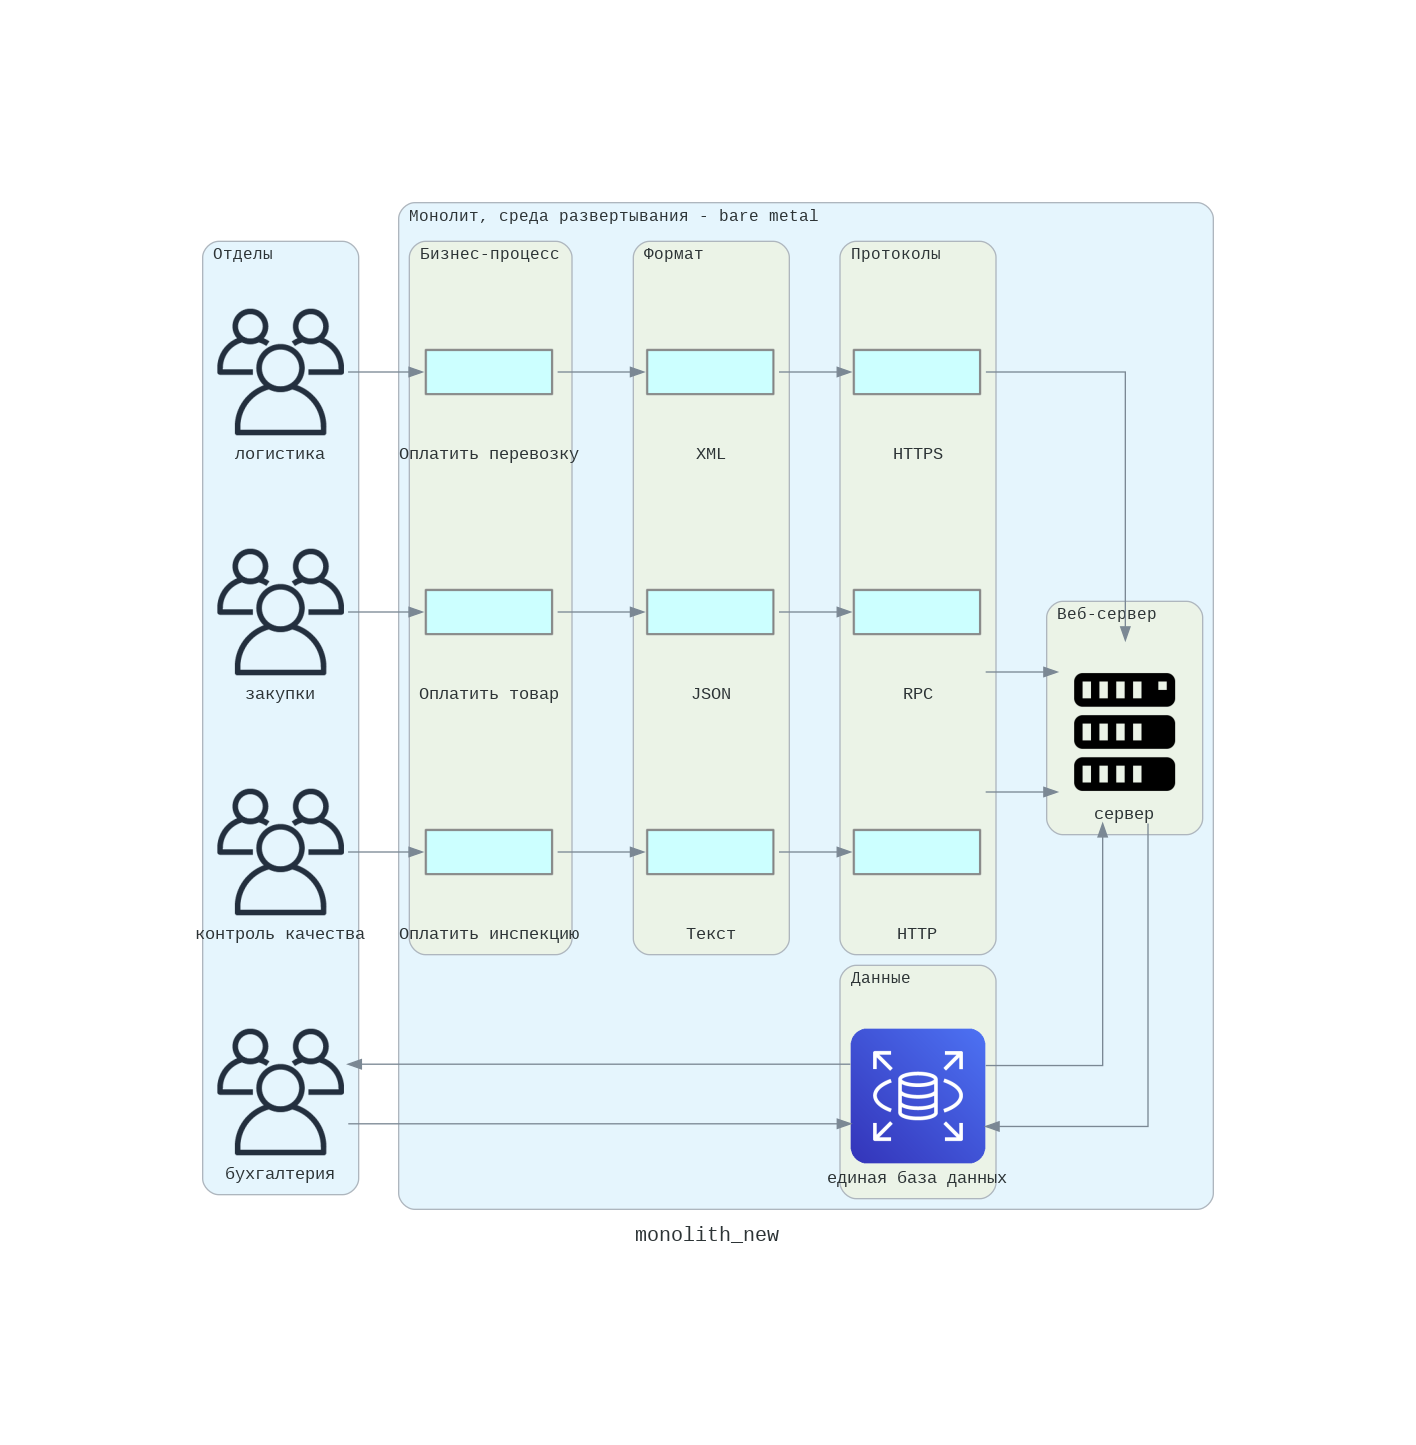

In [8]:
!python diagram.py
image_path = '/content/monolith_new.png'
display(Image(filename=image_path))

Это тот же самый мололит, который был в семинаре и который был использован в качестве примера в задаче 1.

Рассмотрим этот пример уже более подробно в контексте задачи 2.

Решение (ответы на вопросы)

1. Диагностика связности и выбор границ сервисов

Для диагностики связности используется анализ бизнес-доменов (крупных областей деятельности: логистика, закупки, контроль качества, бухгалтерия). Каждый домен имеет свои бизнес-процессы (оплата перевозки, оплата товара, оплата инспекции) и слабо связан с другими - взаимодействие происходит только через единую базу данных. Границы сервисов выбираются именно по этим бизнес-доменам.

2. Приоритет вынесения частей под нагрузку

Первыми выносятся сервисы логистики, закупок и контроля качества, так как именно они генерируют основную нагрузку. Каждый из этих отделов инициирует свой бизнес-процесс, и их вынесение снимет узкое место по пропускной способности веб-сервера. Бухгалтерия выносится позже, так как она работает напрямую с базой данных и не создает дополнительной нагрузки на веб-сервер.

3. Обеспечение совместной работы старого и нового (strangler pattern)

Переход осуществляется по стратегии strangler pattern (поэтапная замена). API-Gateway на входе перенаправляет запросы: сначала все запросы идут в монолит. По мере готовности каждого микросервиса, запросы соответствующего отдела переключаются на новый сервис. Монолит продолжает работать для непереключенных отделов, что позволяет выполнять переход поэтапно и без остановки системы.

4. Владение данными и минимизация рисков согласованности

После разделения каждый микросервис становится единственным владельцем своих данных и получает собственную базу данных. Бухгалтерия, которой нужны данные из всех сервисов, получает доступ только для чтения через API, а не напрямую к базам данных. Для минимизации рисков согласованности используется событийный подход: при изменении данных сервис публикует событие в очередь, а другие сервисы (например, бухгалтерия) подписываются на эти события и обновляют свои копии данных асинхронно.

5. Нужен ли API-Gateway на входе и какие задачи он возьмет

API-Gateway необходим и выполняет следующие задачи: маршрутизация запросов к нужному сервису (монолит или микросервис в зависимости от этапа перехода), аутентификация и авторизация всех входящих запросов, агрегация ответов от нескольких сервисов (например, для формирования сводной отчетности для бухгалтерии), а также ограничение частоты запросов для защиты сервисов от перегрузки.


Исходя из ответов представленных выше можно представить следующую стратегию разбиения монолита

1. Выбор стратегии декомпозиции - по бизнес-доменам (потому что в монолите четко выделяются четыре обособленных домена: логистика, закупки, контроль качества и бухгалтерия. Каждый домен имеет свои бизнес-процессы и слабо связан с другими, что создает естественные границы для разделения.).

2. Приоритет первых выносимых частей - сервисы логистики, закупок и контроля качества (потому что именно эти три отдела создают основную нагрузку. Их вынесение позволит масштабировать каждый сервис независимо и снять проблему перегрузки).

3. Очередность вынесения бухгалтерии - последняя в очереди (потому что бухгалтерия работает напрямую с базой данных, не создавая дополнительной нагрузки на веб-сервер, поэтому ее вынесение не критично для решения проблемы с пропускной способностью).

4. Способ перехода - strangler pattern (поэтапная замена) (это позволяет переключать запросы с монолита на микросервисы постепенно, без остановки системы, и при необходимости откатиться к монолиту в случае проблем).

5. Владение данными - каждый сервис получает свою базу данных (это устраняет узкое место единой базы данных, позволяет выбирать тип БД под задачи каждого сервиса и обеспечивает независимость сервисов друг от друга).

6. Обеспечение согласованности данных - событийный подход через очередь сообщений (это позволяет бухгалтерии и другим сервисам получать актуальные данные асинхронно, без прямого доступа к чужим базам данных, и минимизирует риски рассинхронизации).

7. Необходимость API-Gateway (обеспечивает маршрутизацию запросов к нужному сервису, аутентификацию, агрегацию ответов и ограничение частоты запросов - все это критически важно при переходе с монолита на микросервисы).

In [6]:
# Здесь представлена более подробная схема разбиения по сравнению с заданием 1
# Дополнительно показана очередь сообщений
# ECS - это контейнер (микросервис)
# RDS	- это база данных
# SQS - очередь сообщений (для асинхронной обработки)

# Создаем файл с диаграммой
%%writefile /content/microservices_new.py
from diagrams import Cluster, Diagram, Edge
from diagrams.aws.compute import ECS
from diagrams.aws.network import APIGateway
from diagrams.aws.database import RDS
from diagrams.aws.integration import SQS
from diagrams.onprem.client import Users

with Diagram("microservices_new", show=False):

    # Отделы
    with Cluster("Отделы"):
        depts = [
            Users("логистика"),            # отдел логистики
            Users("закупки"),              # отдел закупок
            Users("контроль качества"),    # отдел контроля качества
            Users("бухгалтерия")           # бухгалтерия
        ]


    # API-Gateway - gринимает все запросы и распределяет их по нужным сервисам
    gateway = APIGateway("api-gateway")

    # Микросервесы (каждый отвечает за свой отдел)
    with Cluster("Микросервисы"):

        # Сервис логистики
        with Cluster("Сервис логистики"):
            logistics_service = ECS("логистика")
            logistics_database = RDS("db логистики")

        # Сервис закупок
        with Cluster("Сервис закупок"):
            procurement_service = ECS("закупки")
            procurement_database = RDS("db закупок")

        # Сервис контроля качества
        with Cluster("Сервис контроля качества"):
            quality_service  = ECS("контроль качества")
            quality_database = RDS("db контроля")

        # Сервис бухгалтерии
        with Cluster("Сервис бухгалтерии"):
            accounting_service = ECS("бухгалтерия")
            accounting_database = RDS("db бухгалтерии")

    # Очередь сообщений
    queue = SQS("очередь сообщений")

    # Связи

    # Отделы отправляют запросы в API Gateway
    depts[0] >> Edge(label="запрос") >> gateway   # логистика
    depts[1] >> Edge(label="запрос") >> gateway   # закупки
    depts[2] >> Edge(label="запрос") >> gateway   # контроль качества
    depts[3] >> Edge(label="запрос") >> gateway   # бухгалтерия

    # API Gateway перенаправляет запросы к нужным сервисам
    gateway >> Edge(label="оплата перевозки") >> logistics_service
    gateway >> Edge(label="оплата товара") >> procurement_service
    gateway >> Edge(label="оплата инспекции") >> quality_service
    gateway >> Edge(label="финансовые операции") >> accounting_service

    # Каждый сервис работает со своей базой данных
    logistics_service >> Edge(label="чтение/запись") >> logistics_database
    procurement_service >> Edge(label="чтение/запись") >> procurement_database
    quality_service >> Edge(label="чтение/запись") >> quality_database
    accounting_service >> Edge(label="чтение/запись") >> accounting_database

    # Сервисы публикуют события в очередь
    logistics_service >> Edge(label="событие", style="dashed") >> queue
    procurement_service >> Edge(label="событие", style="dashed") >> queue
    quality_service >> Edge(label="событие", style="dashed") >> queue

    # Бухгалтерия подписывается на события из очереди
    queue >> Edge(label="подписка", style="dashed") >> accounting_service

Overwriting /content/microservices_new.py


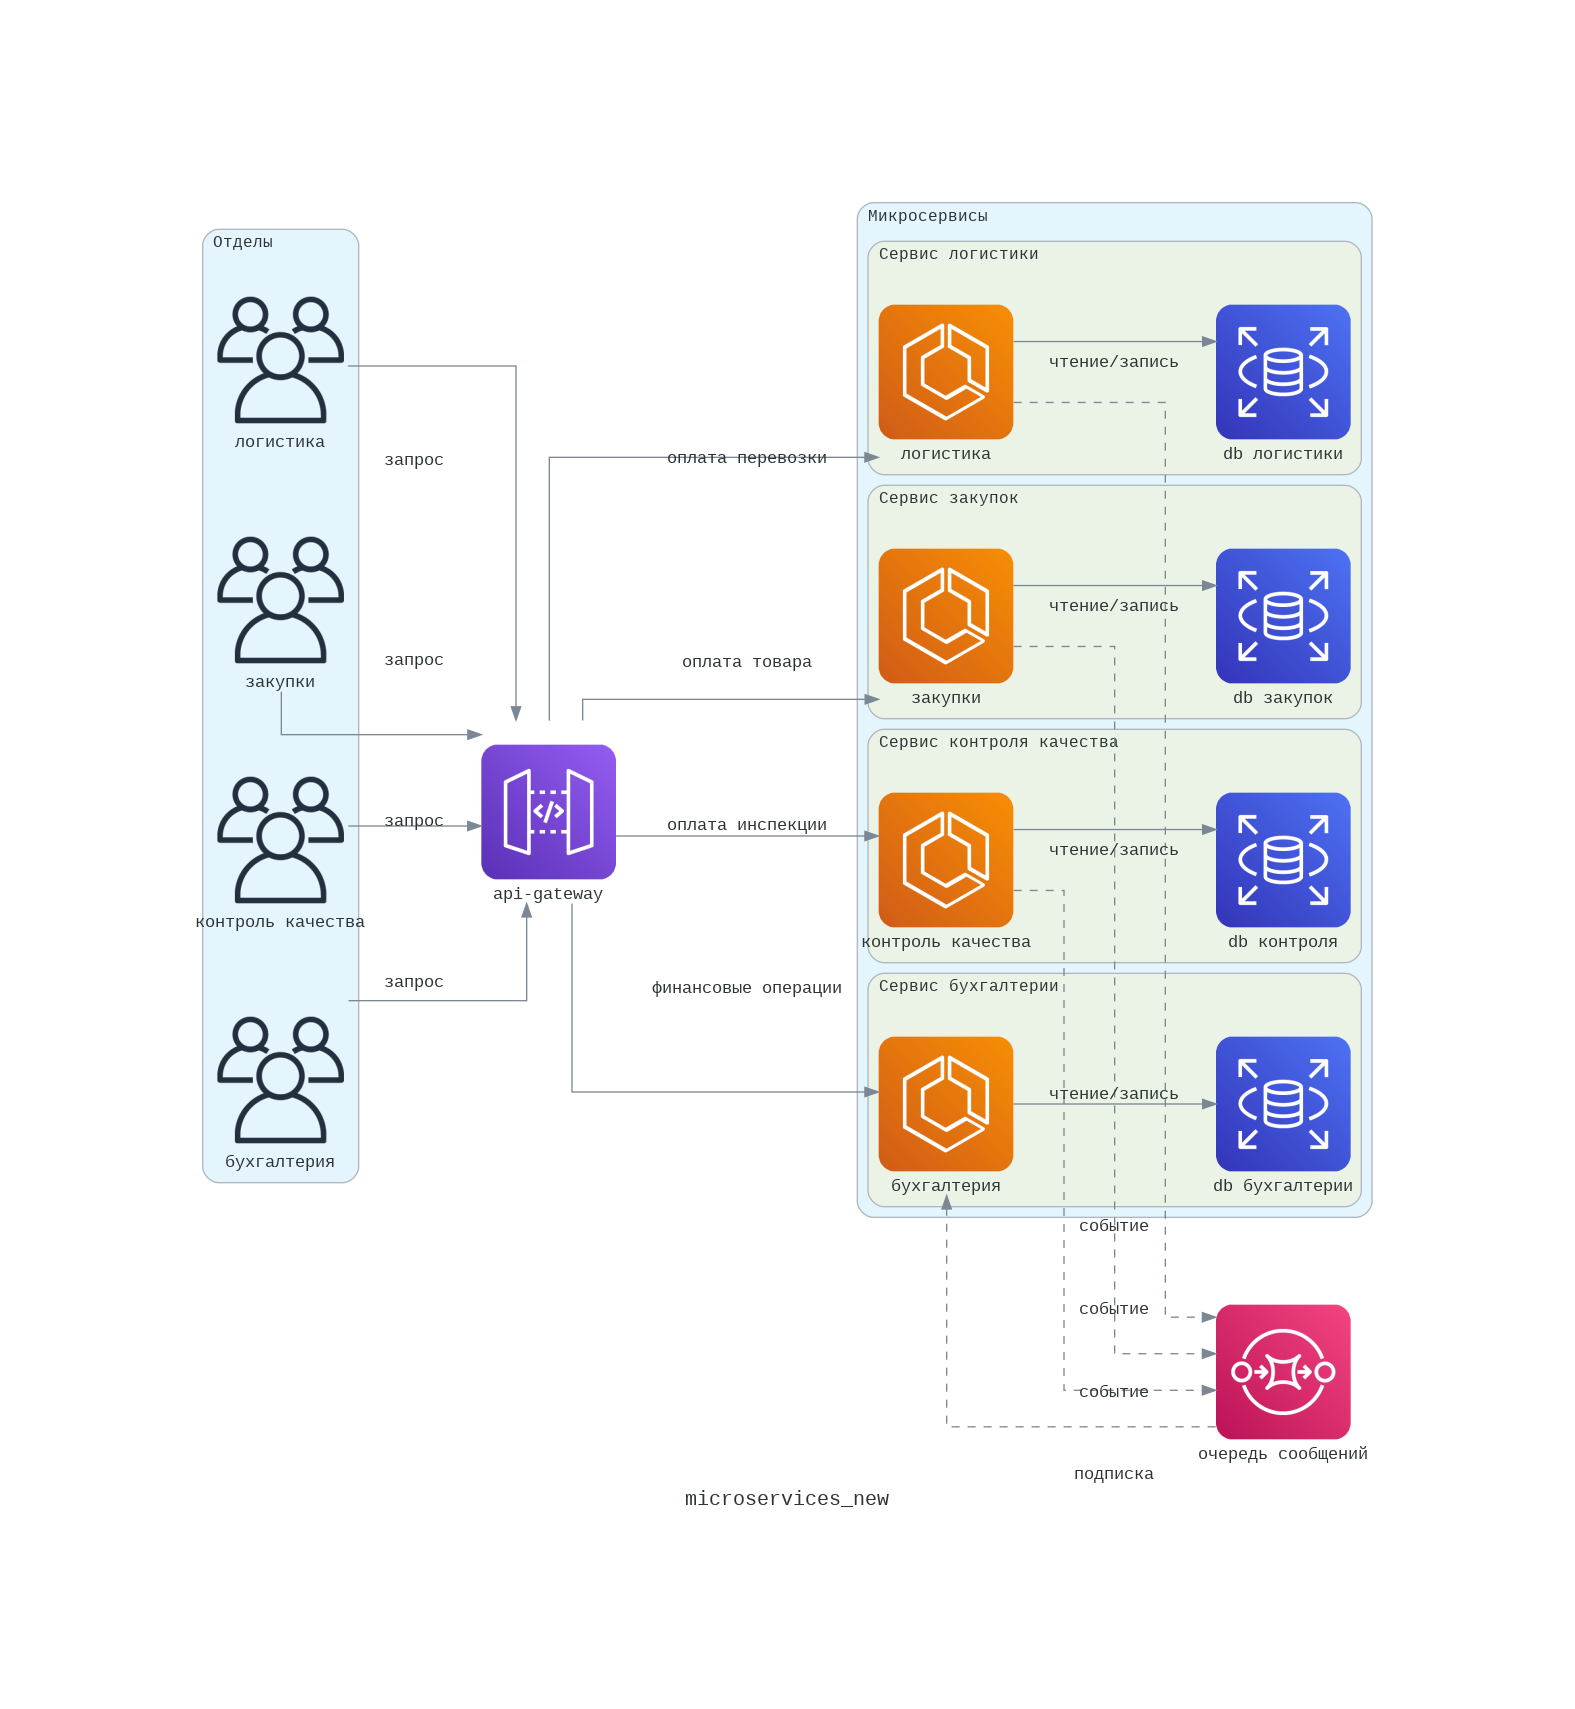

In [7]:
!python /content/microservices_new.py

display(Image(filename='/content/microservices_new.png'))

**Вывод**

Для решения проблемы перегрузки монолита выбрана стратегия разбиения по бизнес-доменам: логистика, закупки, контроль качества и бухгалтерия. Первыми выносятся сервисы логистики, закупок и контроля качества, так как это позволит снять узкое место веб-сервера. Переход выполняется по стратегии strangler pattern через API-Gateway, что обеспечивает поэтапную замену без остановки системы. Каждый микросервис получает свою базу данных, а для согласованности данных используется очередь сообщений: сервисы публикуют события, бухгалтерия подписывается на них. API-Gateway обеспечивает маршрутизацию, аутентификацию и ограничение частоты запросов. Такая архитектура решает проблему перегрузки и позволяет независимо масштабировать каждый сервис.



### Задание 3. Составить документацию взаимодействия сервисов, используя библиотеку docker-compose-diagram

Изучите нотацию библиотеки [Diagrams](https://diagrams.mingrammer.com/docs/nodes/onprem) для указания изображений узлов.

Изучите библиотеку [docker-compose-diagram](https://github.com/skonik/docker-compose-diagram) для документирования докер-компоуз-файлов с помощью лейблов.

Создайте диаграмму простого взаимодействия сервисов (веб-сервер и база данных) добавляя лейблы, чтобы получилось примерно как изображено на рисунке.

%%html

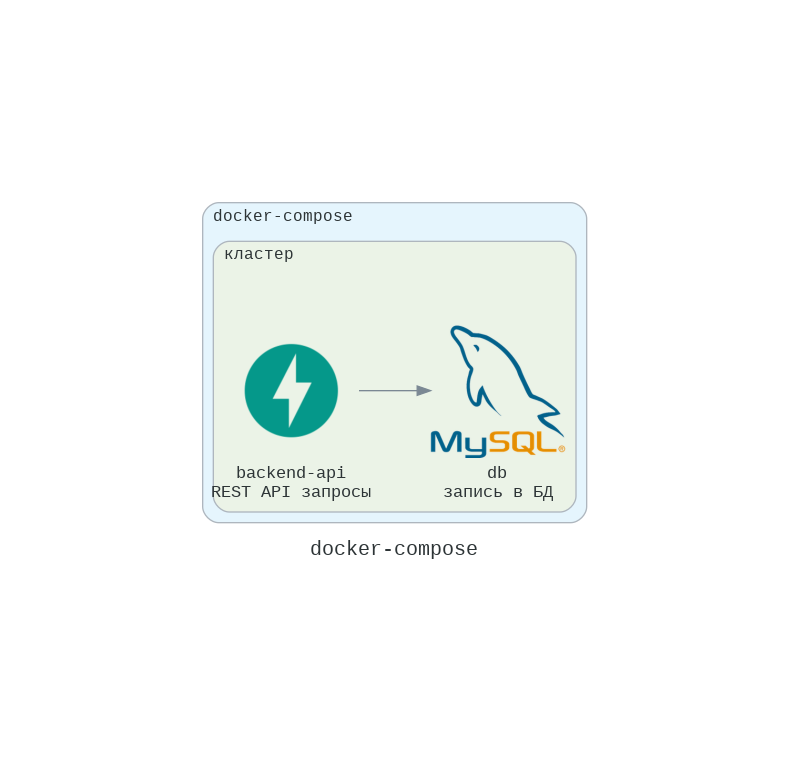

In [ ]:
%%writefile docker-compose.yml
services:

  backend-api:
    build:
      context: ..
      dockerfile: docker/django/Dockerfile
    image: dev_backend
    container_name: dev_backend
    restart: always
    volumes:
      - ..:/app/
    depends_on:
      - db
    working_dir: "/app/backend"
    expose:
      - 8000
    ports:
      - "8000:8000"
    command: runserver
    labels:
      "docker_compose_diagram.icon": "" # выберите diagrams.onprem.compute.Server или diagrams.programming.framework.Django
                                        #diagrams.programming.framework.Fastapi
                                        #diagrams.programming.framework.FastAPI
                                        #diagrams.programming.framework.Flask
      "docker_compose_diagram.cluster": "название"
      "docker_compose_diagram.description": "описание"



  db:
    container_name: backend_api_db
    image: mysql/mysql-server:8
    volumes:
      - mysql_data:/var/lib/mysql
    restart: unless-stopped
    ports:
      - "3306:3306"
    labels:
      "docker_compose_diagram.icon": "" #вставьте diagrams.onprem.database.Mysql, либо diagrams.onprem.database.MySQL
      "docker_compose_diagram.cluster": "название"
      "docker_compose_diagram.description": "описание"

In [ ]:
!compose-diagram --file docker-compose.yml --direction=LR --nodesep=1.2

In [ ]:
image_path = '/content/docker-compose.png'
display(Image(filename=image_path))

### Задание 4. Выбрать подходящие паттерны интеграции сервисов (REST/gRPC/брокеры)

Есть монолитное веб-приложение с пропускной способностью ≈200 RPS, при росте нагрузки до ≈400 RPS начинает ощущаться деградация.

Предложите 3 гипотезы, основываясь на [HDD-подходе](https://colab.research.google.com/drive/1vzl2jhLMJuLN-ZcYiPiIeJ7ribHMGDwt?usp=sharing) и исходя из вводных данных:

## REST (будет выдавать 1000 RPS)
* DevCost = 120000 — зарплата разработчиков.
* InfraCost =  50000 — стоимость инфраструктуры.
* featureEstimate = 85 — оценка фичи в стори-поинтах.
* ReworkRate =  0.2; процент доработок/исправлений — от 0.0 до 1.0.

## gRPC (будет выдавать 10000 RPS)

* DevCost = 1000000 — зарплата разработчиков.
* InfraCost =  500000 — стоимость инфраструктуры.
* featureEstimate = 850 — оценка фичи в стори-поинтах.
* ReworkRate =  0.4; процент доработок/исправлений — от 0.0 до 1.0.

## брокеры (будет выдавать 1000000 RPS)

* DevCost = 1200000 — зарплата разработчиков.
* InfraCost =  1500000 — стоимость инфраструктуры.
* featureEstimate = 8500 — оценка фичи в стори-поинтах.
* ReworkRate =  0.6; процент доработок/исправлений — от 0.0 до 1.0.

### Задание 5. Разработать схему ML-системы для обработки табличных данных

**Писать код не нужно.**

Нужно составить список вопросов, без которых невозможно начать разработку ML-системы, выбрать архитектуру и составить схематическое описание  ML-системы с помощью библиотеки Diagrams.

**Вводные данные от бизнеса: «Как привлечь клиентов на депозит?» и результат прошлой маркетинговой кампании.**

In [ ]:
!pip install scikit-learn -qqq
from sklearn.datasets import fetch_openml
X, y = fetch_openml("bank-marketing", version=1, as_frame=True, return_X_y=True)
display(X.merge(y,left_index=True,right_index=True).tail())
y.value_counts() #<-внес ли клиент срочный депозит по итогам маркетинговой компании? ("да = 2"/"нет = 1")

In [ ]:
#Писать код не нужно !

## Итоговое оформление

1. Сформулируйте ниже 5–8 выводов, когда стоит разбивать монолит на микросервисы.
2. Опишите в 5–8 предложениях ваш подход к декомпозиции монолита.
3. Запустите блокнот, чтобы получить диаграмму простого взаимодействия сервисов (веб-сервер и база данных), используя лейблы.
4. Обоснуйте в 5–8 предложениях выбранный паттерн интеграции сервисов.
5. Без чего немыслимо начинать разработку ML-системы?
6. Проверьте, что ноутбук запускается.  